/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_36894/3615588166.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  sub['frequency'] = sub['count'] / sub['count'].sum()
/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_36894/3615588166.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = plt.cm.get_cmap(base_cmap, 256)
/var/folders/8h/kqm5zszn2q5bhndj3_skhmgh0000gn/T/ipykernel_36894/3615588166.py:52: UserWarning: The following kwargs were not used by contour: 'shading'
  im = ax.contourf(X, Y, Z, cmap=cmap, shading='auto')
/var/folders/8h/kqm5

"\nfig2 = plot_groups(['sche','schd','schp'],\n                   labels=['HSE', 'HSD$^0$', 'HSP$^{+}$'],\n                   title='histidine_angles',\n                   mark_max=False)\n"

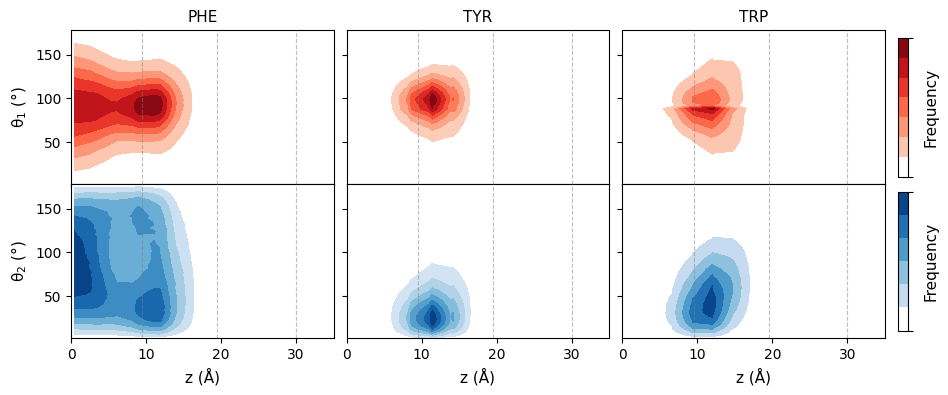

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import numpy.ma as ma
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable

input_dir = '../data/aromatics_orientation/'
output_dir = '../plot/aromatics_orientation/'

font_gap=1

def custom_colormap(base_cmap='Reds', white_ratio=0.1):
    base = plt.cm.get_cmap(base_cmap, 256)
    colors = base(np.linspace(0, 1, 256))
    n_white = int(256 * white_ratio)
    colors[:n_white] = np.array([1, 1, 1, 1])  # blanc RGBA
    return ListedColormap(colors)

def plot_groups(aas, labels, title='aromatics_angles', mark_max=False, individual_cbar=False):
    n = len(aas)
    fig, axes = plt.subplots(2, n,
                             figsize=(n*3.5, 2*2),
                             sharex=True, sharey=True,
                             gridspec_kw={'wspace':0.05, 'hspace':0})

    for j, aa in enumerate(aas):
        df = pd.read_csv(input_dir+f'freq_angle_{aa}.dat', sep='\t') #mono?
        df['z_center'] = df['z_center'].abs()
        df = (df.groupby(['angle_type','z_center','theta_center'], as_index=False)
                ['count'].mean())

        for i, angle in enumerate(['theta1','theta2']):
            ax = axes[i, j]
            sub = df[df['angle_type'] == angle]
            sub['frequency'] = sub['count'] / sub['count'].sum()

            pivot = (sub.pivot(index='theta_center', columns='z_center', values='frequency')
                       .fillna(0)
                       .sort_index().sort_index(axis=1))

            # Normalisation pour garantir que la somme des fréquences = 1
            total = pivot.values.sum()
            if total > 0:
                pivot = pivot / total

            X, Y = np.meshgrid(pivot.columns.values, pivot.index.values)
            #Z = ma.masked_where(pivot.values <= 0.0001, pivot.values)
            Z = pivot.values
            
            cmap = custom_colormap('Reds') if angle == 'theta1' else custom_colormap('Blues')
            im = ax.contourf(X, Y, Z, cmap=cmap, shading='auto')

            ax.set_xlim(0, 35)
            
            # === GRILLE VERTICALE CUSTOM ===
            for z_line in [9.5, 19.5, 30]:
                ax.axvline(x=z_line, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=10)

            # === 1. AFFICHER FREQUENCE MAXIMALE ===
            #freq_max = pivot.values.max()
            #color_square = 'darkred' if angle == 'theta1' else 'darkblue'

            #ax.plot([], [], color=color_square, marker='s', linestyle='None',
                                            #label=f'max freq: {freq_max:.3f}')
            #ax.legend(loc='upper right', fontsize=8-font_gap, frameon=False, handlelength=1.2, handletextpad=0.5)

            # === 2. AJOUTER CROIX ENTRE Z=10 ET 20 ===
            if mark_max:
                sub_z = sub[(sub['z_center'] >= 10) & (sub['z_center'] <= 20)]
                if not sub_z.empty:
                    max_row = sub_z.loc[sub_z['frequency'].idxmax()]
                    ax.plot(max_row['z_center'], max_row['theta_center'],
                            mfc='none', color='k',
                            marker='o', markersize=6, label='max z∈[10,20]')

            if i == 0:
                ax.set_title(labels[aas.index(aa)].upper(), pad=6, fontsize=12-font_gap)
            if j == 0:
                ax.set_ylabel('θ$_1$ (°)' if i==0 else 'θ$_2$ (°)', fontsize=12-font_gap)
            if i == 1:
                ax.set_xlabel('z (Å)', fontsize=12-font_gap)
            if individual_cbar:
                cbar = fig.colorbar(im, ax=ax, location='top', orientation='horizontal',
                                    pad=0.01, aspect=20, shrink=0.7)
                ticks = np.linspace(im.get_clim()[0], im.get_clim()[1], 3)
                cbar.set_ticks(ticks)
                cbar.set_ticklabels([f"{t:.3f}" for t in ticks])
                cbar.ax.tick_params(labelsize=8-font_gap)
            elif j == n-1:
                # Créer un axe colorbar réduit et centré manuellement
                # Position: [x, y, width, height] en coordonnées de l'axe
                # x=1.05 pour le placer à droite, y=0 pour centrer (0% de marge en bas)
                # width=0.03, height=0.9 (90% de la hauteur)
                cax = ax.inset_axes([1.05, 0.05, 0.04, 0.9], transform=ax.transAxes)
                cbar = fig.colorbar(im, cax=cax)
                cbar.set_ticks([im.get_clim()[0], im.get_clim()[1]])
                #cbar.set_ticklabels(['low','high'], fontsize=20)
                cbar.set_ticklabels(['',''], fontsize=10-font_gap)
                cbar.ax.tick_params(labelsize=12-font_gap)
                cbar.set_label("Frequency", rotation=90, fontsize=12-font_gap)
            #elif j == n-1:
            #    # Utiliser make_axes_locatable pour créer un axe colorbar sans comprimer le graphique
            #    divider = make_axes_locatable(ax)
            #    cax = divider.append_axes("right", size="5%", pad=0.1)
            #    cbar = fig.colorbar(im, cax=cax, shrink=0.7)
            #    cbar.set_ticks([im.get_clim()[0], im.get_clim()[1]])
            #    #cbar.set_ticklabels(['low','high'], fontsize=20)
            #    cbar.set_ticklabels(['',''], fontsize=10-font_gap)
            #    cbar.ax.tick_params(labelsize=12-font_gap)
            #    cbar.set_label("Frequency", rotation=90, fontsize=12-font_gap)
            #elif j == n-1:
            #    cbar = fig.colorbar(im, ax=ax, location='right', pad=0.05, shrink=0.8)
            #    cbar.set_ticks([im.get_clim()[0], im.get_clim()[1]])
            #    #cbar.set_ticklabels(['low','high'], fontsize=20)
            #    cbar.set_ticklabels(['',''], fontsize=10-font_gap)
            #    cbar.ax.tick_params(labelsize=12-font_gap)
            #    cbar.set_label("Frequency", rotation=90, fontsize=12-font_gap)
    
    # Créer le colorbar pour toute la dernière colonne (ne compresse pas les graphiques)
    #if not individual_cbar:
    #    cbar = fig.colorbar(im, ax=axes[:, -1], location='right', pad=0.02, shrink=0.8)
    #    cbar.set_ticks([im.get_clim()[0], im.get_clim()[1]])
    #    cbar.set_ticklabels(['',''], fontsize=10-font_gap)
    #    cbar.ax.tick_params(labelsize=12-font_gap)
    #    cbar.set_label("Frequency", rotation=90, fontsize=12-font_gap)

    plt.savefig(output_dir+f'{title}.png', dpi=600, bbox_inches='tight')
    return fig

"""
fig1 = plot_groups(['scf', 'scy','scym', 'scw'],
                   labels=['PHE', 'TYR', 'TYR$^{-}$', 'TRP'],
                   title='aromatics_angles',
                   mark_max=False,
                   individual_cbar=False)
"""

fig1 = plot_groups(['scf', 'scy', 'scw'],
                   labels=['PHE', 'TYR', 'TRP'],
                   title='aromatics_angles',
                   mark_max=False,
                   individual_cbar=False)

"""
fig2 = plot_groups(['sche','schd','schp'],
                   labels=['HSE', 'HSD$^0$', 'HSP$^{+}$'],
                   title='histidine_angles',
                   mark_max=False)
"""
